In [16]:
import os
import shutil
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib
import kagglehub


In [17]:
plantvillage_path = kagglehub.dataset_download(
    "abdallahalidev/plantvillage-dataset"
)

plant_disease_path = kagglehub.dataset_download(
    "karagwaanntreasure/plant-disease-detection"
)

print(plantvillage_path)
print(plant_disease_path)

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Using Colab cache for faster access to the 'plant-disease-detection' dataset.
/kaggle/input/plantvillage-dataset
/kaggle/input/plant-disease-detection


In [18]:

# Duplicate folder names existed. So I just cleaned them up
CLASS_MAPPING = {
    "Corn_(maize)___healthy": "Maize_Healthy",
    "Corn_(maize)___Common_rust_": "Maize_Common_Rust",
    "Corn_(maize)___Northern_Leaf_Blight": "Maize_Northern_Leaf_Blight",
    "Tomato___healthy": "Tomato_Healthy",
    "Tomato_healthy": "Tomato_Healthy",
    "Tomato___Early_blight": "Tomato_Early_Blight",
    "Tomato_Early_blight": "Tomato_Early_Blight",
    "Tomato___Late_blight": "Tomato_Late_Blight",
    "Tomato_Late_blight": "Tomato_Late_Blight",
    "Tomato___Leaf_Mold": "Tomato_Leaf_Mold",
    "Tomato_Leaf_Mold": "Tomato_Leaf_Mold",
    "Black Pod Rot": "Cocoa_Black_Pod_Rot",
    "Pod Borer": "Cocoa_Pod_Borer",
    "Healthy": "Cocoa_Healthy"
}

def create_unified_dataset(source_dir, target_dir):
    target_dir = Path(target_dir)
    target_dir.mkdir(parents=True, exist_ok=True)

    for folder in Path(source_dir).iterdir():
        if folder.is_dir() and folder.name in CLASS_MAPPING:
            clean_name = CLASS_MAPPING[folder.name]
            dest_folder = target_dir / clean_name
            dest_folder.mkdir(exist_ok=True)

            for img in folder.iterdir():
                if img.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                    # Copy image using unique filename to avoid overwriting
                    shutil.copy(img, dest_folder / f"{folder.name}_{img.name}")

print("Class mapping defined for 7 unified target classes")

Class mapping defined for 7 unified target classes


In [19]:


def remove_duplicates(dataset_dir):
    seen_hashes = set()
    duplicates_removed = 0

    for root, _, files in os.walk(dataset_dir):
        for file in files:
            file_path = os.path.join(root, file)
            with open(file_path, 'rb') as f:
                file_hash = hashlib.md5(f.read()).hexdigest()

            if file_hash in seen_hashes:
                os.remove(file_path)
                duplicates_removed += 1
            else:
                seen_hashes.add(file_hash)

    print(f"Cleaned dataset! Removed {duplicates_removed} duplicate images.")

In [20]:
plantvillage_path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")
plant_disease_path = kagglehub.dataset_download("karagwaanntreasure/plant-disease-detection")
cocoa_path = kagglehub.dataset_download("zaldyjr/cacao-diseases")


pv_color = Path(plantvillage_path) / "plantvillage dataset" / "color"
second_ds = Path(plant_disease_path) / "Dataset"
clean_dataset_dir = Path("/content/clean_crop_dataset")
cocoa_dir = Path(cocoa_path) / "cacao_diseases" / "cacao_photos"

#Unifiying the datasets
create_unified_dataset(pv_color, clean_dataset_dir)
create_unified_dataset(second_ds, clean_dataset_dir)

#Removing duplicate files across merged datasets
remove_duplicates(clean_dataset_dir)

# Verifying the clean 7-class directory output
print("\nClean Unified Dataset Structure:")
for folder in clean_dataset_dir.iterdir():
    if folder.is_dir():
        print(f"  └─ {folder.name}: {len(list(folder.iterdir()))} unique images")

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Using Colab cache for faster access to the 'plant-disease-detection' dataset.
Using Colab cache for faster access to the 'cacao-diseases' dataset.
Cleaned dataset! Removed 5484 duplicate images.

Clean Unified Dataset Structure:
  └─ Tomato_Healthy: 1585 unique images
  └─ Maize_Northern_Leaf_Blight: 2116 unique images
  └─ Maize_Healthy: 2084 unique images
  └─ Tomato_Early_Blight: 1000 unique images
  └─ Tomato_Late_Blight: 1901 unique images
  └─ Tomato_Leaf_Mold: 952 unique images
  └─ Maize_Common_Rust: 2144 unique images


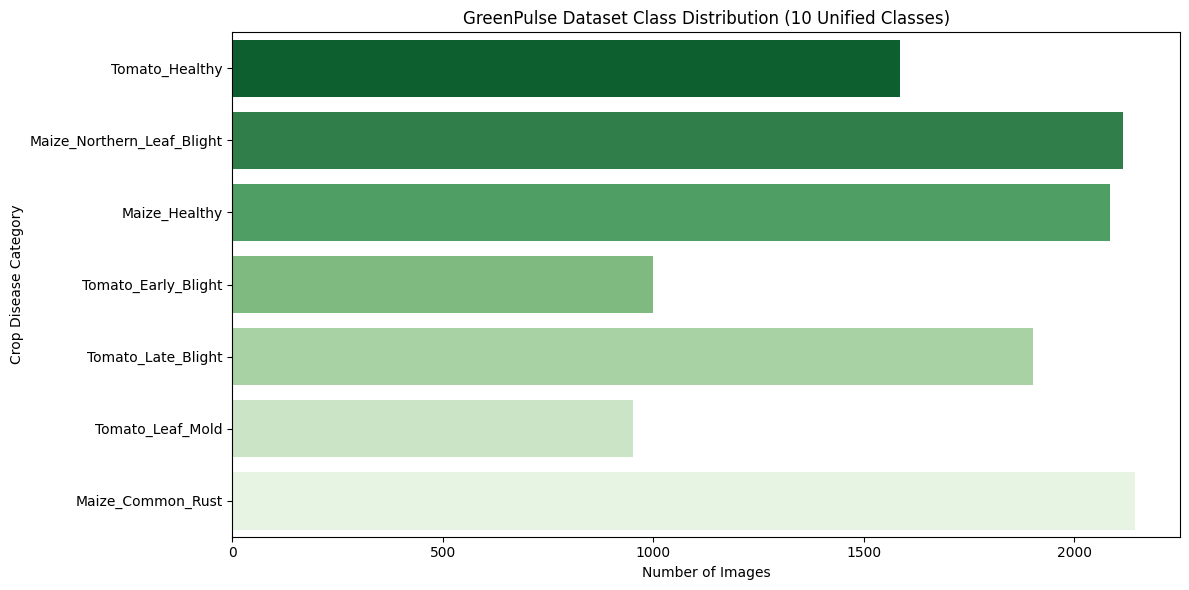

In [22]:
# Count images per unified class and plot
counts = {folder.name: len(list(folder.iterdir())) for folder in clean_dataset_dir.iterdir() if folder.is_dir()}

plt.figure(figsize=(12, 6))
sns.barplot(x=list(counts.values()), y=list(counts.keys()), hue=list(counts.keys()), palette="Greens_r", legend=False)
plt.title("GreenPulse Dataset Class Distribution (10 Unified Classes)")
plt.xlabel("Number of Images")
plt.ylabel("Crop Disease Category")
plt.tight_layout()
plt.savefig("dataset_distribution.png")
plt.show()